# Q-factorisation on Four Rooms

In [14]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms_discrete import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBufferDiscrete, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from networks import DQN_QNetwork


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def get_base_env(env):
    return env.unwrapped

def collect_valid_states_fourrooms(env):
    """
    Use FourRoomsGridWorld._free_cells directly.
    Since obs = agent position, the valid observations are just the free cells.
    """
    base_env = get_base_env(env)

    if not hasattr(base_env, "_free_cells"):
        raise RuntimeError("Base env does not expose _free_cells.")

    coords = np.asarray(base_env._free_cells, dtype=np.int32)      # [N, 2]
    states = coords.astype(np.float32)                             # obs == (x, y)

    return states, coords

def shared_pca_projection(emb_before, emb_after, n_components=2):
    X = np.concatenate([emb_before, emb_after], axis=0)
    pca = PCA(n_components=n_components)
    Xp = pca.fit_transform(X)
    Z_before = Xp[:emb_before.shape[0]]
    Z_after = Xp[emb_before.shape[0]:]
    return Z_before, Z_after, pca

def plot_before_after(Z_before, Z_after, label_before, label_after, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(Z_before[:, 0], Z_before[:, 1], s=25, alpha=0.7, label=label_before)
    plt.scatter(Z_after[:, 0], Z_after[:, 1], s=25, alpha=0.7, label=label_after)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [16]:
class FactorisedDQN_QNetwork(nn.Module):

    def __init__(
        self,
        obs_dim: int,
        num_actions: int,
        goal_dim: int = 2,
        hidden_dim: int = 128,
        rep_dim: int = 64,
    ):
        super().__init__()
        self.num_actions = num_actions
        self.goal_dim = goal_dim
        self.rep_dim = rep_dim

        # Environment / state encoder: s -> phi_s(s) in R^rep_dim
        self.obs_encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
            nn.ReLU(),
        )

        # Action embedding: a -> e_a in R^rep_dim
        self.action_emb = nn.Embedding(num_actions, rep_dim)

        # Goal / task encoder: z -> psi(z) in R^rep_dim
        self.goal_encoder = nn.Sequential(
            nn.Linear(goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

    def forward(self, obs: torch.Tensor, goal: torch.Tensor) -> torch.Tensor:
        B = obs.shape[0]

        phi_s = torch.tanh(self.obs_encoder(obs))
        psi_z = torch.tanh(self.goal_encoder(goal))

        phi_s = F.normalize(phi_s, p=2, dim=-1, eps=1e-8)
        psi_z = F.normalize(psi_z, p=2, dim=-1, eps=1e-8)
        action_emb = F.normalize(torch.tanh(self.action_emb.weight), p=2, dim=-1, eps=1e-8)
        phi_sa = F.normalize(phi_s.unsqueeze(1) * action_emb.unsqueeze(0), p=2, dim=-1, eps=1e-8)
        q_vals = (phi_sa * psi_z.unsqueeze(1)).sum(dim=-1)
        
        return q_vals
    
    def encode_state(self, obs: torch.Tensor) -> torch.Tensor:
        """
        Return normalized phi(s) in R^rep_dim for a batch of states.
        obs: [B, obs_dim]
        """
        phis = torch.tanh(self.obs_encoder(obs))
        return F.normalize(phis, p=2, dim=-1, eps=1e-8)             # [B, D]

    def encode_goal(self, goal: torch.Tensor) -> torch.Tensor:
        """
        Return normalized psi(z) in R^rep_dim for a batch of goals.
        goal: [B, goal_dim]
        """
        psiz = torch.tanh(self.goal_encoder(goal))
        return F.normalize(psiz, p=2, dim=-1, eps=1e-8)             # [B, D]

    def encode_actions(self) -> torch.Tensor:
        """
        Return normalized action embeddings e_a in R^rep_dim for all actions.
        """
        ea = torch.tanh(self.action_emb.weight)                     # [A, D]
        return F.normalize(ea, p=2, dim=-1, eps=1e-8)               # [A, D]

    def encode_state_action(self, obs: torch.Tensor) -> torch.Tensor:
        """
        Return normalized phi(s,a) for a batch of states and all actions.
        obs: [B, obs_dim]
        Output: [B, num_actions, rep_dim]
        """
        phis = self.encode_state(obs)                               # [B, D]
        ea = self.encode_actions()                                  # [A, D]

        phisa = phis.unsqueeze(1) + ea.unsqueeze(0)                 # [B, A, D]
        return F.normalize(phisa, p=2, dim=-1, eps=1e-8)            # [B, A, D]

In [17]:
def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env


psi norm 52.04277038574219
psi norm 51.469146728515625
psi norm 76.67544555664062
psi norm 40.70087814331055
psi norm 4.368931293487549
psi norm 2.905456304550171
psi norm 2.9698832035064697
psi norm 2.8928256034851074
psi norm 2.8070731163024902
psi norm 2.6282382011413574
psi norm 2.5582633018493652
psi norm 2.5201621055603027
psi norm 2.4658241271972656
psi norm 2.460983991622925
psi norm 2.4792137145996094
psi norm 2.4852561950683594
psi norm 2.4560346603393555
psi norm 2.4708406925201416
psi norm 2.490447998046875


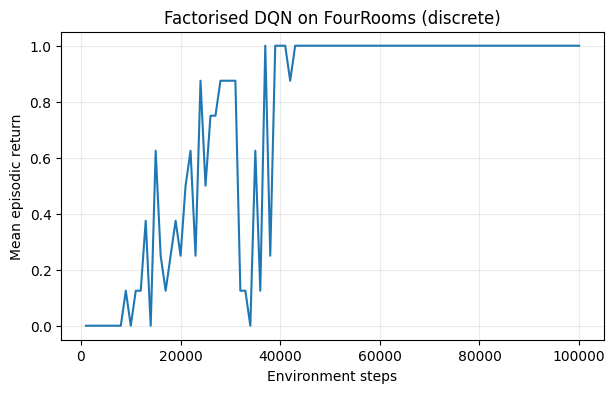

In [18]:
BUFFER_CAPACITY = 100000
GOAL = (9, 9)
LR = float(1e-3)

env = make_env(goal=GOAL)
obs_dim = env.observation_space.shape[0]
num_actions = env.action_space.n


# Factorised Q-network instead of plain DQN_QNetwork
# Goal is 2-D (grid coordinates), so goal_dim=2
q_net = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)

q_target = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)

q_target.load_state_dict(q_net.state_dict())
for p in q_target.parameters():
    p.requires_grad_(False)


def dqn_train(
    q_network=q_net,
    q_target_network=q_target,
    env=env,
    buffer_capacity=BUFFER_CAPACITY,
    lr=LR,
    obs_dim=obs_dim,
    device=DEVICE,
    total_steps=100000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=50000,
    train_freq=4,
    goal=GOAL,
    params=None,
):

    if params is None:
        opt = optim.Adam([
            {"params": q_network.obs_encoder.parameters(), "lr": 1e-3},
            {"params": q_network.action_emb.parameters(), "lr": 1e-3},
            {"params": q_network.goal_encoder.parameters(), "lr": 3e-3},
        ])
    else:
        opt = optim.Adam(params, lr=3e-3)

    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    # goal tensor: broadcasted later for batches
    goal_arr = np.array(goal, dtype=np.float32)
    goal_t_single = torch.tensor(goal_arr, dtype=torch.float32, device=device).unsqueeze(0)

    obs, _ = env.reset()
    global_step = 0
    eval_returns = []

    ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = (
        [],
        [],
        [],
        [],
        [],
        [],
    )

    while global_step < total_steps:
        # Epsilon-greedy action selection
        frac = min(1.0, global_step / eps_decay_steps)
        eps = eps_start + frac * (eps_end - eps_start)

        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                q_vals = q_network(obs_t, goal_t_single)  # [1, A]
                action = int(q_vals.argmax(dim=-1).item())

        next_obs, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        ep_obs.append(obs.copy())
        ep_actions.append(action)
        ep_rewards.append(float(rew))
        ep_next_obs.append(next_obs.copy())
        ep_terminated.append(float(term))
        ep_truncated.append(float(trunc))

        obs = next_obs
        global_step += 1

        if done:
            episode = {
                "obs": ep_obs,
                "actions": ep_actions,
                "rewards": ep_rewards,
                "next_obs": ep_next_obs,
                "terminated": ep_terminated,
                "truncated": ep_truncated,
            }
            buffer.add_episode(episode)
            ep_obs, ep_actions, ep_rewards, ep_next_obs, ep_terminated, ep_truncated = (
                [],
                [],
                [],
                [],
                [],
                [],
            )
            obs, _ = env.reset()

        # Training update
        if len(buffer) >= warmup_steps and global_step % train_freq == 0:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs                             # [B, obs_dim]
            act_t = batch.actions.long()                  # [B, 1]
            rew_t = batch.rewards                         # [B, 1]
            next_obs_t = batch.next_obs                   # [B, obs_dim]
            term_t = batch.terminated                     # [B, 1]

            # Build goal batch: same goal repeated for each transition
            goal_batch = goal_t_single.expand(obs_t.shape[0], -1)  # [B, goal_dim]

            with torch.no_grad():
                # future discounted return term: gamma * max_{a'} Q^-(s',a';z)
                next_q_vals = q_target_network(next_obs_t, goal_batch)  # [B, A]
                next_q = next_q_vals.max(dim=-1, keepdim=True).values   # [B, 1]
                target = rew_t + gamma * (1.0 - term_t) * next_q        # [B, 1]

                psi_norm = q_network.goal_encoder(goal_batch).norm(dim=-1).mean().item()
                if global_step % 5000 == 0:
                    print("psi norm", psi_norm)

            # current Q(s,a;z)
            current_q_all = q_network(obs_t, goal_batch)                # [B, A]
            current_q = current_q_all.gather(1, act_t.unsqueeze(1))     # [B, 1]

            loss = F.mse_loss(current_q, target)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_network.parameters(), 10.0)
            opt.step()

            # Soft update target network
            for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        if global_step % 1000 == 0:
            eval_env = make_env(goal)
            goal_eval_arr = np.array(goal, dtype=np.float32)
            goal_eval_t = torch.tensor(goal_eval_arr, dtype=torch.float32, device=device).unsqueeze(0)

            def eval_policy(o):
                o_t = torch.tensor(o, dtype=torch.float32, device=device).unsqueeze(0)
                with torch.no_grad():
                    q_vals = q_network(o_t, goal_eval_t)
                    return int(q_vals.argmax(dim=-1).item())

            mean_ret, mean_len = evaluate_policy(eval_env, eval_policy, episodes=8)
            eval_returns.append((global_step, mean_ret))
            # print(
            #     f"[DQN-factorised] step={global_step:7d} | eps={eps:.3f} "
            #     f"| eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}"
            # )
            eval_env.close()

    env.close()
    return q_network, eval_returns


# Train on the original goal
dqn_q_first, dqn_eval_first = dqn_train()

if dqn_eval_first:
    xs, ys = zip(*dqn_eval_first)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("Factorised DQN on FourRooms (discrete)")
    plt.grid(alpha=0.25)
    plt.show()

## Visualisations

Episode 1: 14 steps | return: 1.00 | reached goal: True
Episode 2: 4 steps | return: 1.00 | reached goal: True
Episode 3: 11 steps | return: 1.00 | reached goal: True
Episode 4: 14 steps | return: 1.00 | reached goal: True
Episode 5: 3 steps | return: 1.00 | reached goal: True
Episode 6: 8 steps | return: 1.00 | reached goal: True
Episode 7: 1 steps | return: 1.00 | reached goal: True
Episode 8: 9 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


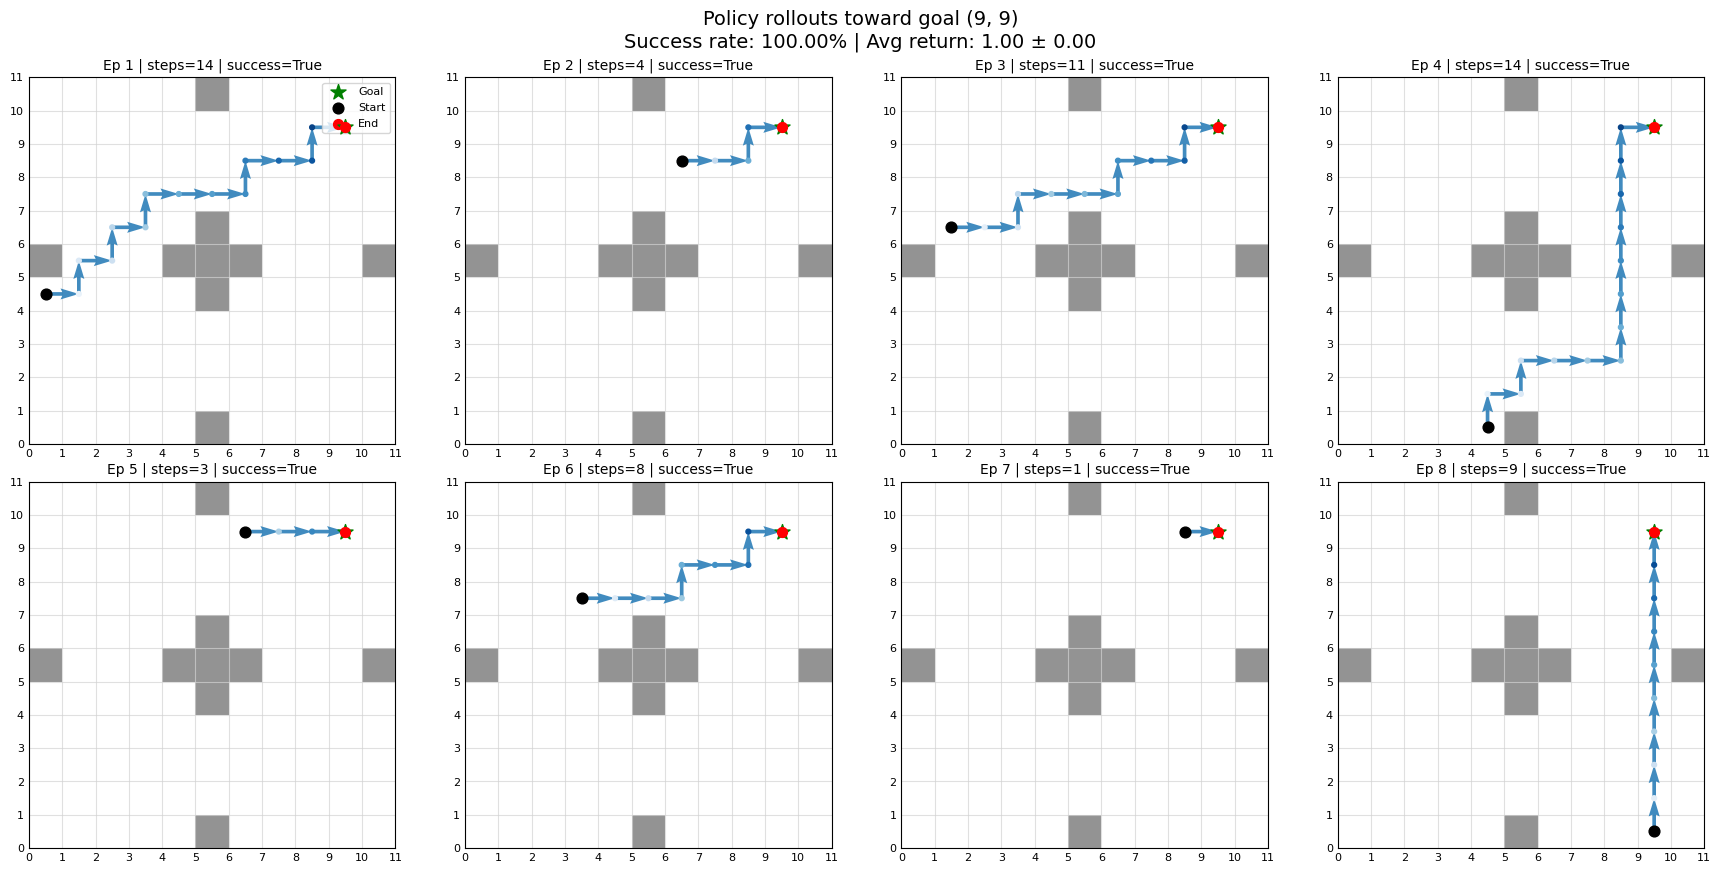

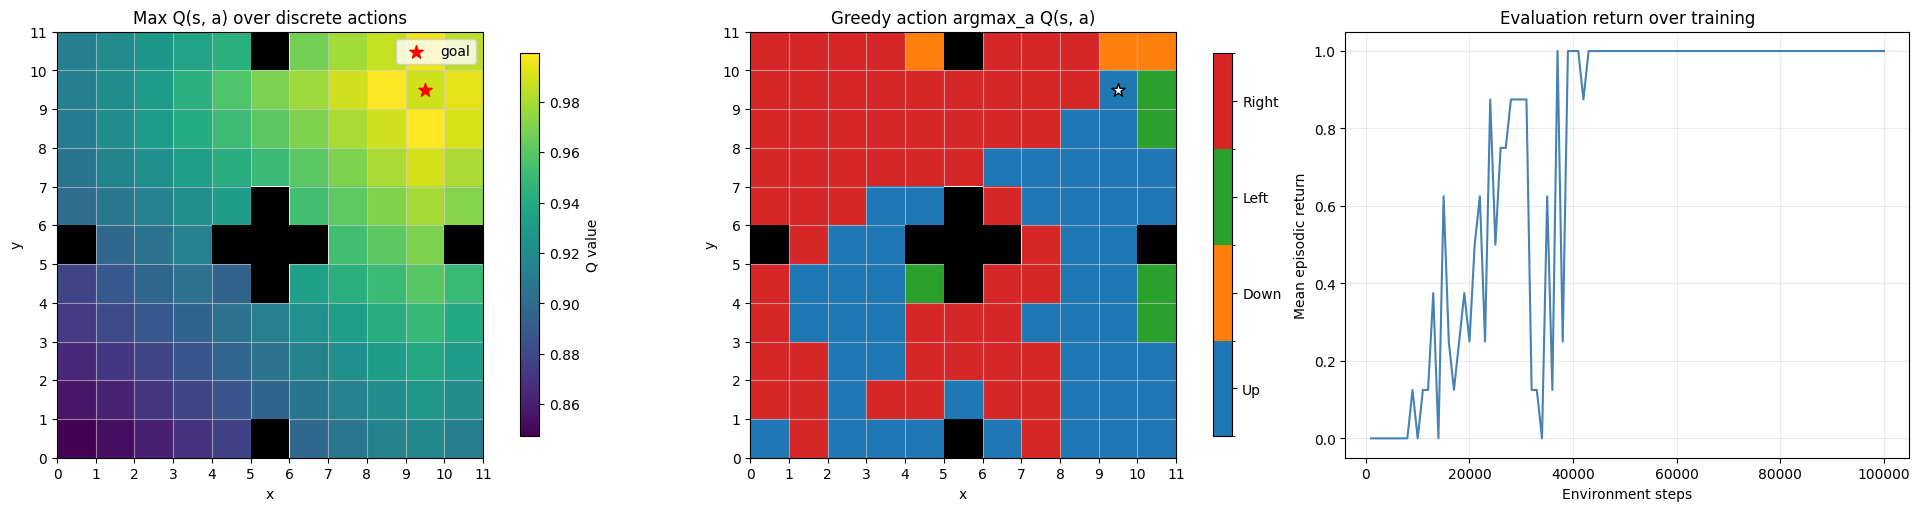

FactorisedDQN_QNetwork(
  (obs_encoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (action_emb): Embedding(4, 64)
  (goal_encoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
  )
)

In [19]:
dqn_q_first.eval()
eval_env_first = make_env(goal=GOAL)


def dqn_policy_fn(obs, q_network, goal):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    goal_arr = np.array(goal, dtype=np.float32)
    goal_t = torch.tensor(goal_arr, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        q_vals = q_network(obs_t, goal_t)
        action = int(q_vals.argmax(dim=-1).item())
    return action


def dqn_value_fn(obs_batch, q_network, goal):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    B = obs_t.shape[0]
    goal_arr = np.array(goal, dtype=np.float32)
    goal_t = torch.tensor(goal_arr, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    goal_batch = goal_t.expand(B, -1)
    with torch.no_grad():
        q_vals = q_network(obs_t.to(DEVICE), goal_batch.to(DEVICE)).cpu().numpy()
    return q_vals


plot_policy_rollouts(
    env=eval_env_first,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_first, goal=GOAL),
    goal_pos=GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=eval_env_first,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_first, goal=GOAL),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=["Up", "Down", "Left", "Right"],
    goal_pos=GOAL,
    eval_returns=dqn_eval_first,
)

eval_env_first.close()
dqn_q_first.train()

states_base: (112, 2)
coords_base: (112, 2)
phi(s) base: (112, 64)
phi(s,a) base: (112, 4, 64)
psi(z) base: (1, 64)
[GOAL=(9, 9)] phi(s,a) norms: mean=1.0000, std=0.0000
[GOAL=(9, 9)] top 5 singular values: [8.550021  8.225478  6.9062476 3.7085898 2.9168394]
[GOAL=(9, 9)] cumulative variance (first 5 dims): [0.32731292 0.630249   0.8438057  0.9053866  0.9434804 ]


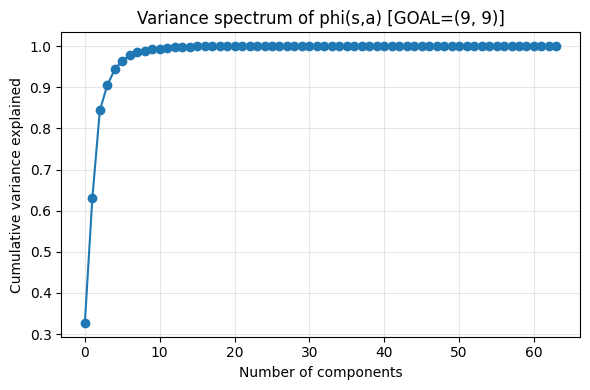

[GOAL=(9, 9)] cos(phi(s,a), psi): mean=-0.4544, std=0.0411


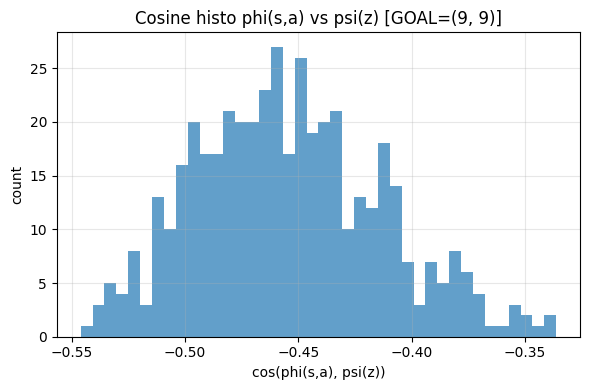

In [20]:
# === BASE TASK EMBEDDINGS ===

base_goal = np.array(GOAL, dtype=np.float32)
base_goal_t = torch.tensor(base_goal, dtype=torch.float32, device=DEVICE).unsqueeze(0)

states_base, coords_base = collect_valid_states_fourrooms(eval_env_first)
obs_base_t = torch.tensor(states_base, dtype=torch.float32, device=DEVICE)

dqn_q_first.eval()
with torch.no_grad():
    phi_s_base = dqn_q_first.encode_state(obs_base_t).cpu().numpy()          # [N, D]
    psi_z_base = dqn_q_first.encode_goal(base_goal_t).cpu().numpy()          # [1, D]
    phi_sa_base = dqn_q_first.encode_state_action(obs_base_t).cpu().numpy()  # [N, A, D]

N_base, A_base, D_base = phi_sa_base.shape
phi_sa_base_flat = phi_sa_base.reshape(N_base * A_base, D_base)

print("states_base:", states_base.shape)
print("coords_base:", coords_base.shape)
print("phi(s) base:", phi_s_base.shape)
print("phi(s,a) base:", phi_sa_base.shape)
print("psi(z) base:", psi_z_base.shape)

def analyze_embeddings(phisa_flat, psi_vec, label="base"):
    """
    phisa_flat: [N*A, D] numpy array of phi(s,a)
    psi_vec: [1, D] numpy array of psi(z)
    """
    # Convert to torch
    phisa_t = torch.tensor(phisa_flat, dtype=torch.float32)
    psi_t   = torch.tensor(psi_vec.squeeze(0), dtype=torch.float32)  # [D]

    # 1) Norm statistics
    norms = phisa_t.norm(dim=-1)   # [N*A]
    print(f"[{label}] phi(s,a) norms: mean={norms.mean().item():.4f}, std={norms.std().item():.4f}")

    # 2) Effective rank (via singular values)
    # Center first to remove mean
    phisa_centered = phisa_t - phisa_t.mean(dim=0, keepdim=True)
    U, S, Vh = torch.linalg.svd(phisa_centered, full_matrices=False)
    S_np = S.cpu().numpy()
    explained = (S_np ** 2) / (S_np ** 2).sum()
    cumulative = explained.cumsum()

    print(f"[{label}] top 5 singular values:", S_np[:5])
    print(f"[{label}] cumulative variance (first 5 dims):", cumulative[:5])

    # Optional: plot variance spectrum
    plt.figure(figsize=(6, 4))
    plt.plot(cumulative, marker="o")
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative variance explained")
    plt.title(f"Variance spectrum of phi(s,a) [{label}]")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3) Cosine similarities between phi(s,a) and psi(z)
    psi_unit = psi_t / (psi_t.norm() + 1e-8)              # ensure unit norm
    phisa_unit = phisa_t / (phisa_t.norm(dim=-1, keepdim=True) + 1e-8)

    cos = (phisa_unit @ psi_unit)                        # [N*A]
    cos_np = cos.cpu().numpy()

    print(f"[{label}] cos(phi(s,a), psi): mean={cos_np.mean():.4f}, std={cos_np.std():.4f}")
    plt.figure(figsize=(6, 4))
    plt.hist(cos_np, bins=40, alpha=0.7)
    plt.xlabel("cos(phi(s,a), psi(z))")
    plt.ylabel("count")
    plt.title(f"Cosine histo phi(s,a) vs psi(z) [{label}]")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage:

# Base goal
analyze_embeddings(phi_sa_base_flat, psi_z_base, label=f"GOAL={GOAL}")

## Now to check how much samples needed to reach a new goal

psi norm 9.841863632202148
psi norm 5.085021495819092
psi norm 3.168274402618408
psi norm 3.3161933422088623
psi norm 2.6944117546081543
psi norm 2.4766340255737305
psi norm 2.650923252105713
psi norm 2.426551580429077
psi norm 2.2857553958892822
psi norm 2.2631735801696777
psi norm 2.222519874572754
psi norm 2.163541793823242
psi norm 2.1261603832244873
psi norm 2.0972800254821777
psi norm 2.0211386680603027
psi norm 2.022976875305176
psi norm 2.0241599082946777
psi norm 2.013796329498291
psi norm 2.004007339477539


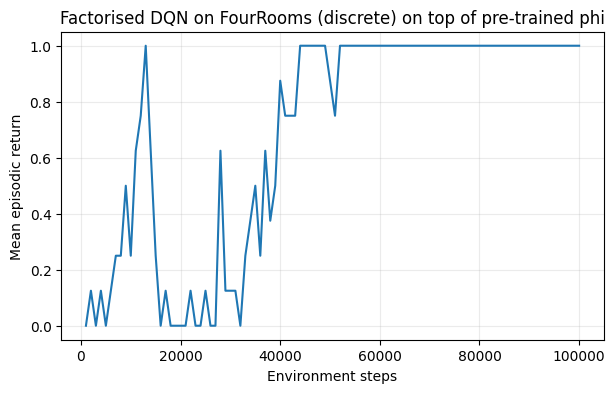

In [21]:
NEW_GOAL = (9, 1)

new_env = make_env(goal=NEW_GOAL)

# New target network initialised from the first trained factorised network
q_target_new = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)
q_target_new.load_state_dict(dqn_q_first.state_dict())
for p in q_target_new.parameters():
    p.requires_grad_(False)

# Freeze environment representation (phi) and action embedding in q_net;
# only allow psi (goal encoder) to adapt to the new goal.
# for p in dqn_q_first.obs_encoder.parameters():
#     p.requires_grad_(False)
# for p in dqn_q_first.action_emb.parameters():
#     p.requires_grad_(False)
# for p in dqn_q_first.goal_encoder.parameters():
#     p.requires_grad_(True)

# Train only psi(goal) parameters on the new goal
dqn_q_new, dqn_eval_new = dqn_train(
    env=new_env,
    q_network=dqn_q_first,             # same network, re-used env representation
    q_target_network=q_target_new,
    goal=NEW_GOAL,
    # params=dqn_q_first.goal_encoder.parameters(),  # only psi updated
)

if dqn_eval_new:
    xs, ys = zip(*dqn_eval_new)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("Factorised DQN on FourRooms (discrete) on top of pre-trained phi")
    plt.grid(alpha=0.25)
    plt.show()

Episode 1: 6 steps | return: 1.00 | reached goal: True
Episode 2: 16 steps | return: 1.00 | reached goal: True
Episode 3: 12 steps | return: 1.00 | reached goal: True
Episode 4: 9 steps | return: 1.00 | reached goal: True
Episode 5: 2 steps | return: 1.00 | reached goal: True
Episode 6: 11 steps | return: 1.00 | reached goal: True
Episode 7: 9 steps | return: 1.00 | reached goal: True
Episode 8: 9 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


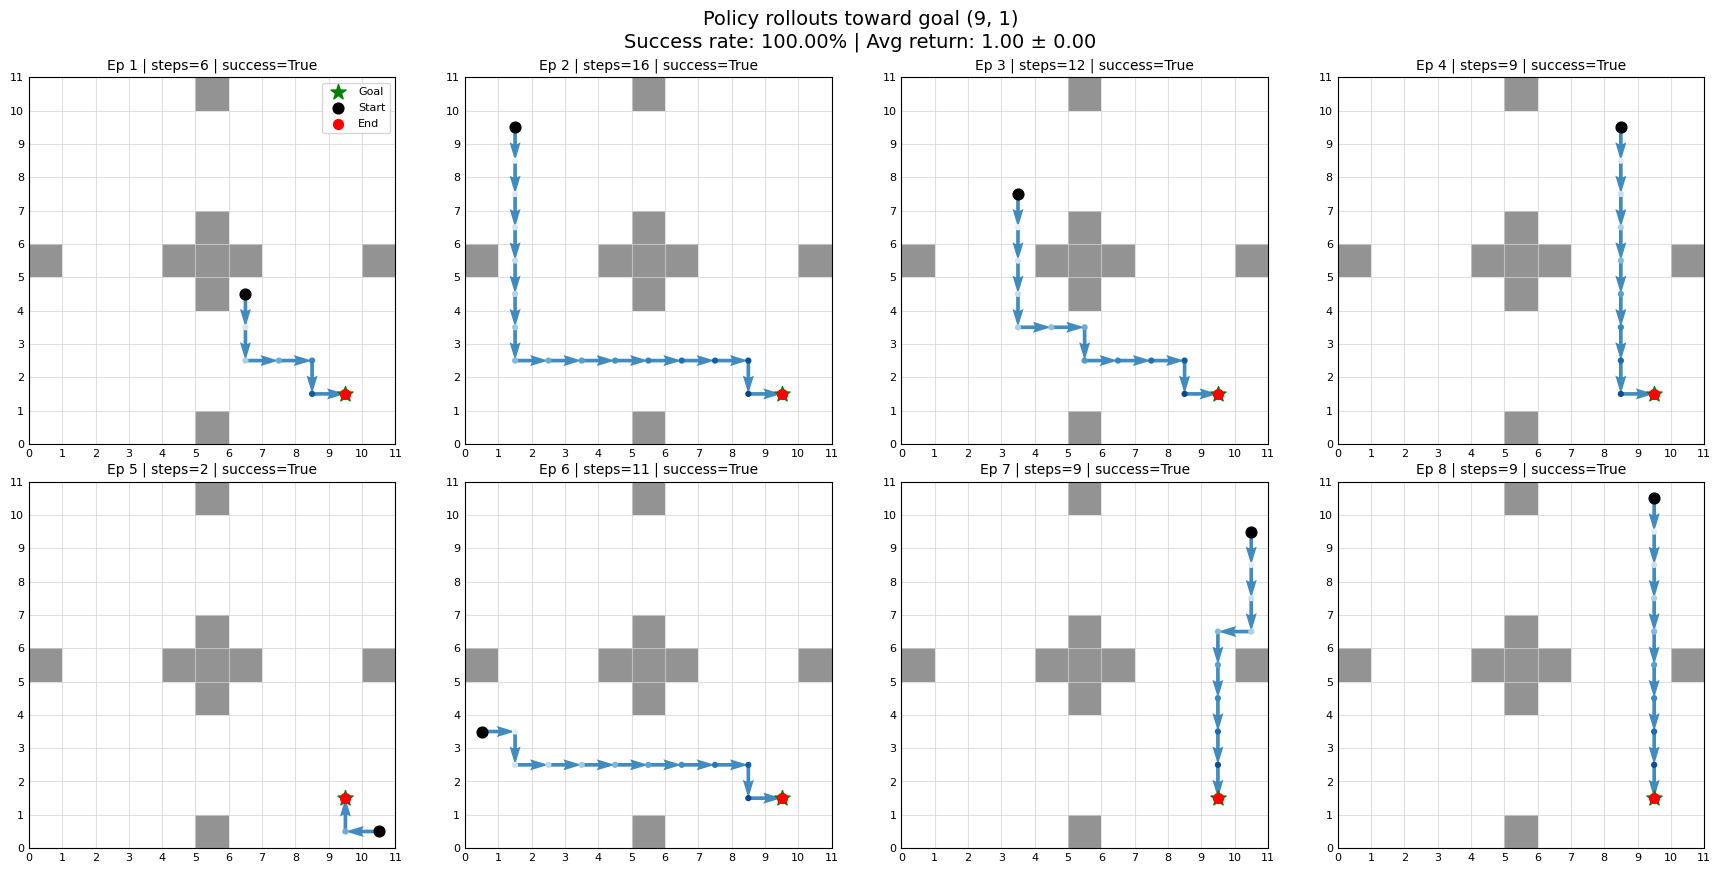

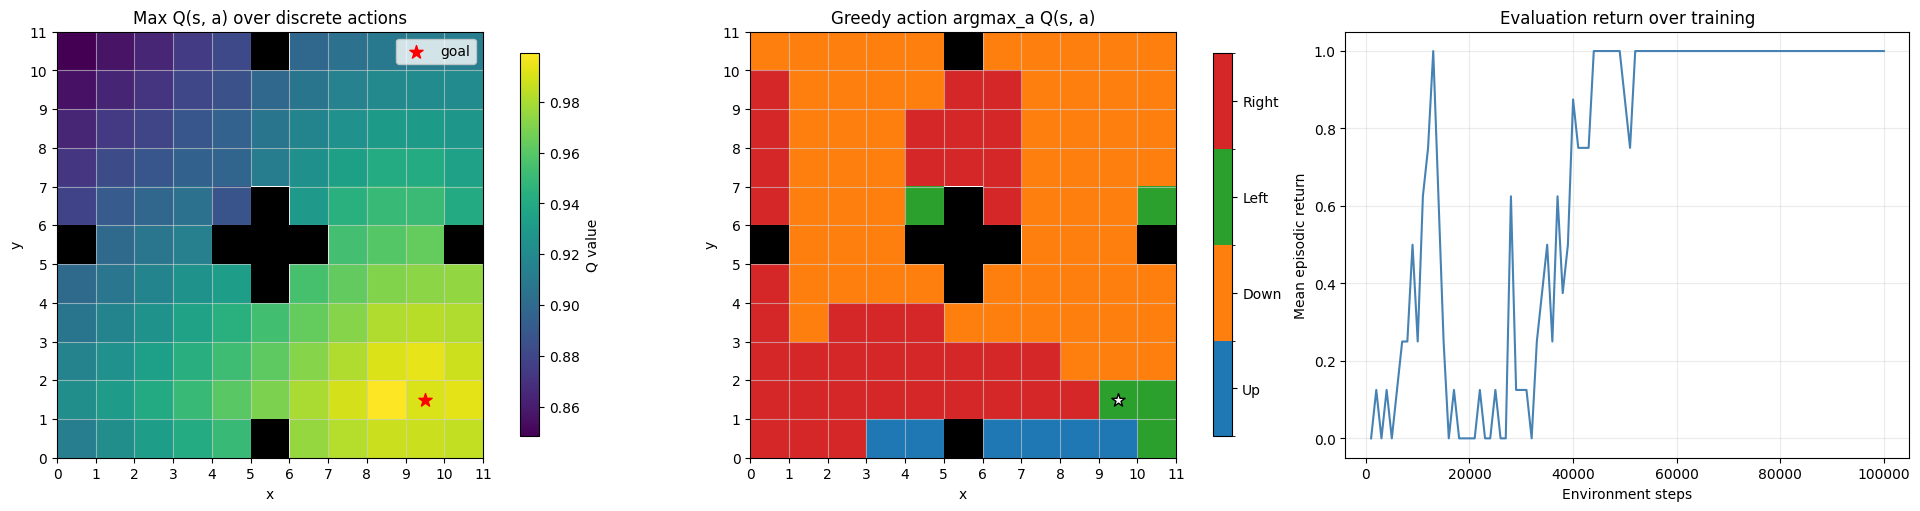

In [22]:

dqn_q_new.eval()
eval_env_new = make_env(goal=NEW_GOAL)


plot_policy_rollouts(
    env=eval_env_new,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_new, goal=NEW_GOAL),
    goal_pos=NEW_GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=eval_env_new,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_new, goal=NEW_GOAL),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=NEW_GOAL,
    eval_returns=dqn_eval_new,
)

eval_env_new.close()


phi(s) transfer: (112, 64)
phi(s,a) transfer: (112, 4, 64)
psi(z) transfer: (1, 64)


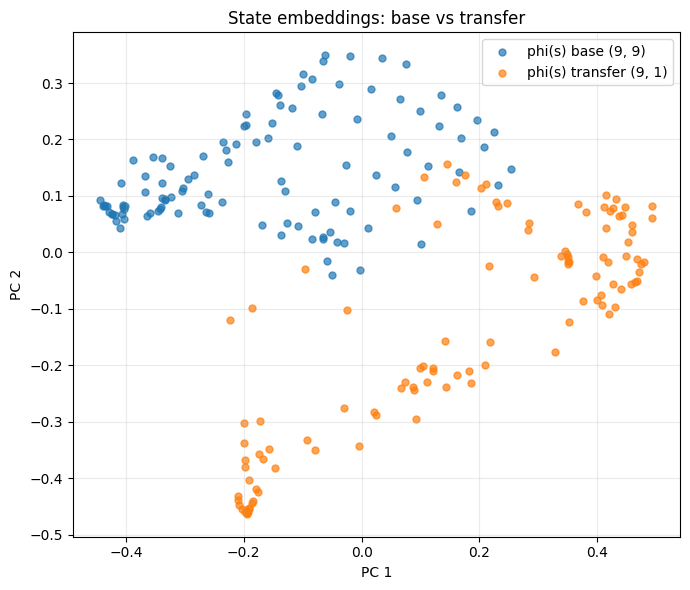

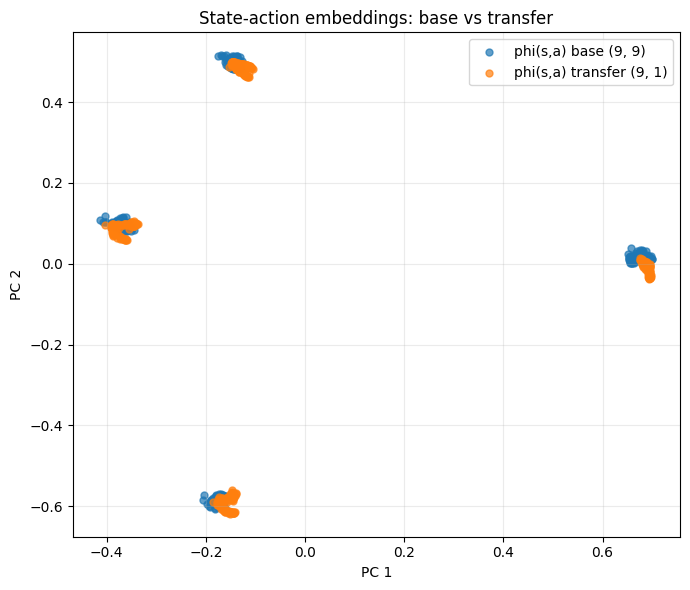

[NEW_GOAL=(9, 1)] phi(s,a) norms: mean=1.0000, std=0.0000
[NEW_GOAL=(9, 1)] top 5 singular values: [8.60874   8.171317  6.8156195 5.163105  3.0320287]
[NEW_GOAL=(9, 1)] cumulative variance (first 5 dims): [0.3126279  0.59429276 0.79024905 0.9027019  0.94148254]


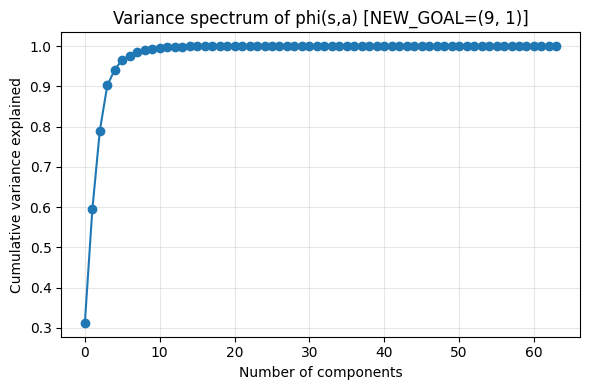

[NEW_GOAL=(9, 1)] cos(phi(s,a), psi): mean=-0.4132, std=0.0627


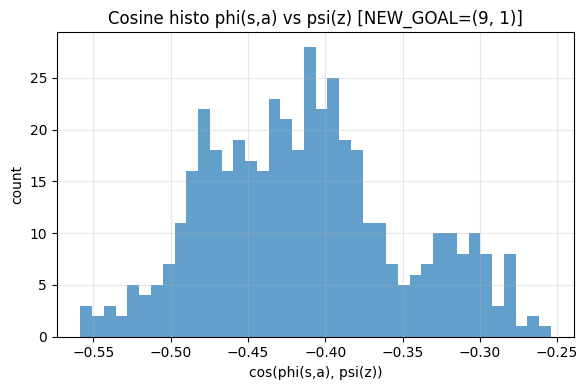

In [23]:
# === TRANSFER TASK EMBEDDINGS ===

transfer_goal = np.array(NEW_GOAL, dtype=np.float32)
transfer_goal_t = torch.tensor(transfer_goal, dtype=torch.float32, device=DEVICE).unsqueeze(0)

states_transfer, coords_transfer = collect_valid_states_fourrooms(eval_env_new)
obs_transfer_t = torch.tensor(states_transfer, dtype=torch.float32, device=DEVICE)

dqn_q_new.eval()
with torch.no_grad():
    phi_s_transfer = dqn_q_new.encode_state(obs_transfer_t).cpu().numpy()
    psi_z_transfer = dqn_q_new.encode_goal(transfer_goal_t).cpu().numpy()
    phi_sa_transfer = dqn_q_new.encode_state_action(obs_transfer_t).cpu().numpy()

N_t, A_t, D_t = phi_sa_transfer.shape
phi_sa_transfer_flat = phi_sa_transfer.reshape(N_t * A_t, D_t)

print("phi(s) transfer:", phi_s_transfer.shape)
print("phi(s,a) transfer:", phi_sa_transfer.shape)
print("psi(z) transfer:", psi_z_transfer.shape)

Z_phi_base, Z_phi_transfer, _ = shared_pca_projection(phi_s_base, phi_s_transfer)
plot_before_after(
    Z_phi_base, Z_phi_transfer,
    f"phi(s) base {GOAL}",
    f"phi(s) transfer {NEW_GOAL}",
    "State embeddings: base vs transfer"
)

Z_phisa_base, Z_phisa_transfer, _ = shared_pca_projection(phi_sa_base_flat, phi_sa_transfer_flat)
plot_before_after(
    Z_phisa_base, Z_phisa_transfer,
    f"phi(s,a) base {GOAL}",
    f"phi(s,a) transfer {NEW_GOAL}",
    "State-action embeddings: base vs transfer"
)

# After transfer to NEW_GOAL
analyze_embeddings(phi_sa_transfer_flat, psi_z_transfer, label=f"NEW_GOAL={NEW_GOAL}")

## ABA test to check whether the old policy gets affected

Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 500 steps | return: 0.00 | reached goal: False
Episode 4: 500 steps | return: 0.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


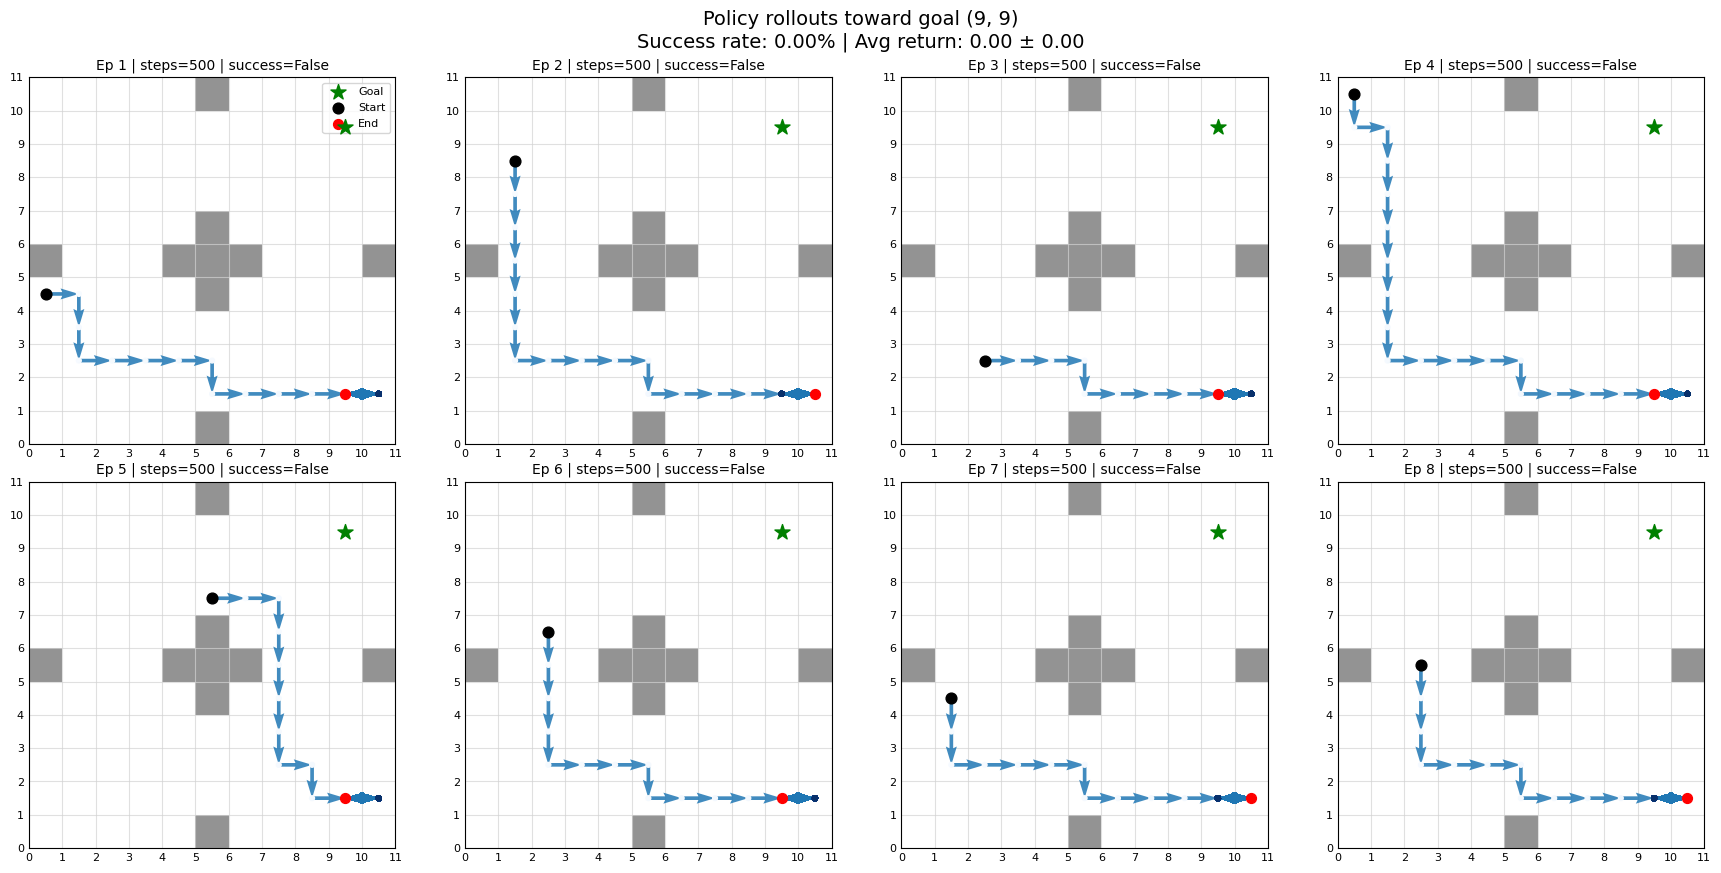

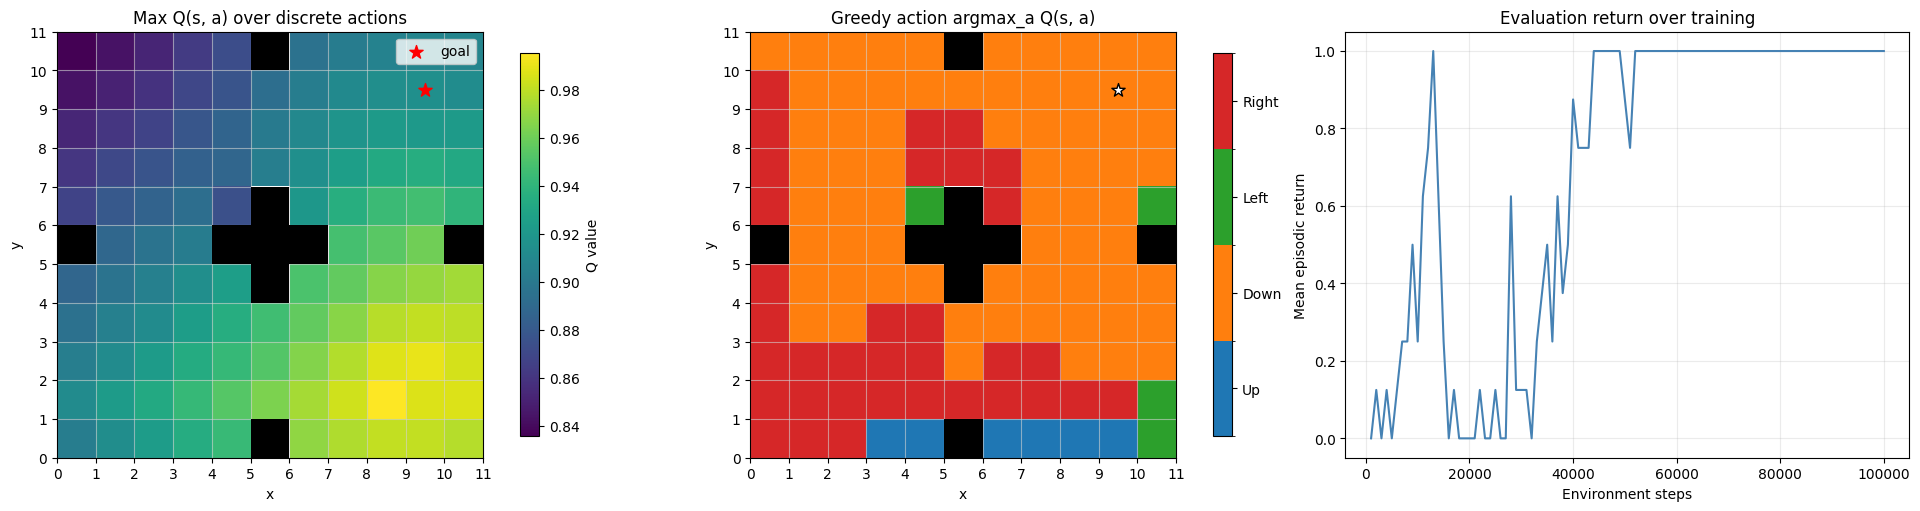

In [25]:


new_env = make_env(goal=GOAL)

plot_policy_rollouts(
    env=new_env,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_new, goal=GOAL),
    goal_pos=GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=new_env,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_new, goal=GOAL),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=GOAL,
    eval_returns=dqn_eval_new,
)

new_env.close()

psi norm 17.01900291442871
psi norm 12.606934547424316
psi norm 8.324310302734375
psi norm 6.231869697570801
psi norm 5.4084367752075195
psi norm 5.451175689697266
psi norm 5.5116753578186035
psi norm 5.438652515411377
psi norm 5.343602180480957
psi norm 5.099468231201172
psi norm 5.113361835479736
psi norm 5.061384201049805
psi norm 4.99948787689209
psi norm 4.93936014175415
psi norm 4.903110980987549
psi norm 4.848951816558838
psi norm 4.809254169464111
psi norm 4.772314071655273
psi norm 4.738820552825928


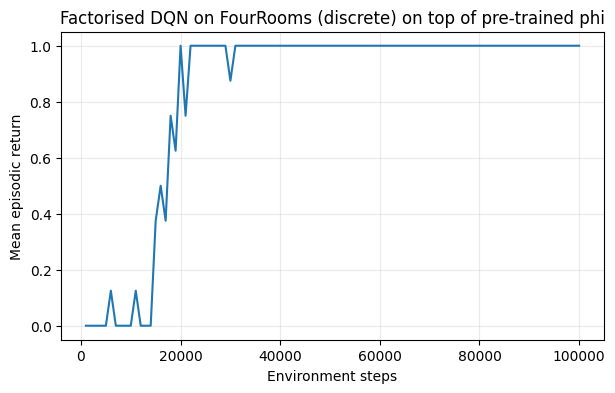

Episode 1: 8 steps | return: 1.00 | reached goal: True
Episode 2: 3 steps | return: 1.00 | reached goal: True
Episode 3: 3 steps | return: 1.00 | reached goal: True
Episode 4: 2 steps | return: 1.00 | reached goal: True
Episode 5: 2 steps | return: 1.00 | reached goal: True
Episode 6: 6 steps | return: 1.00 | reached goal: True
Episode 7: 4 steps | return: 1.00 | reached goal: True
Episode 8: 14 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


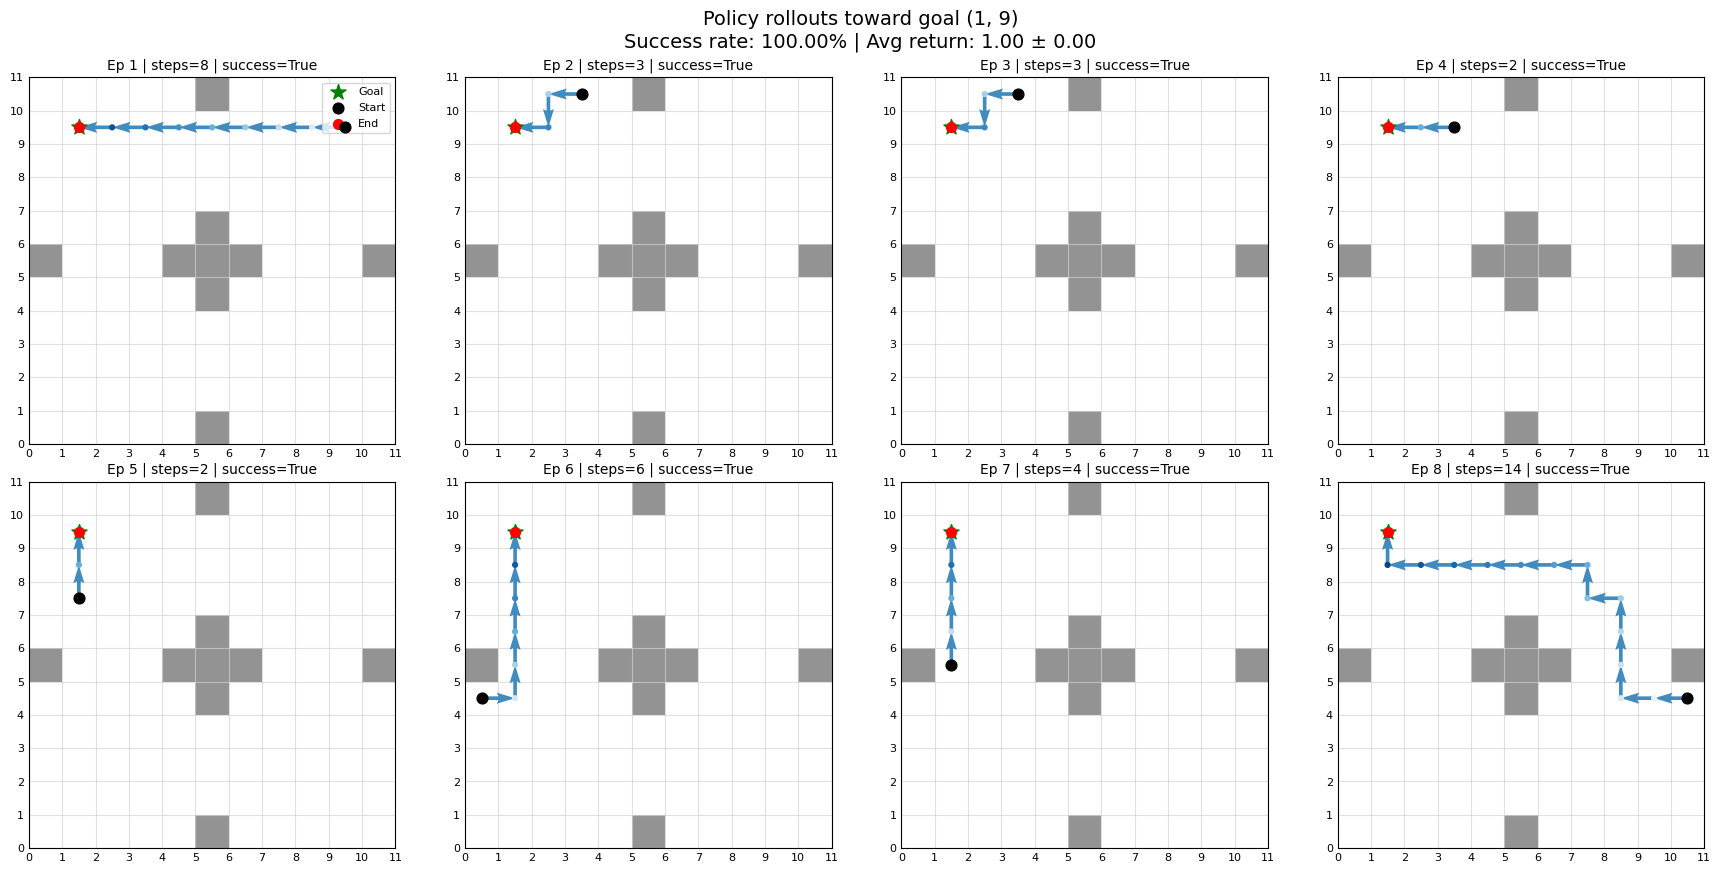

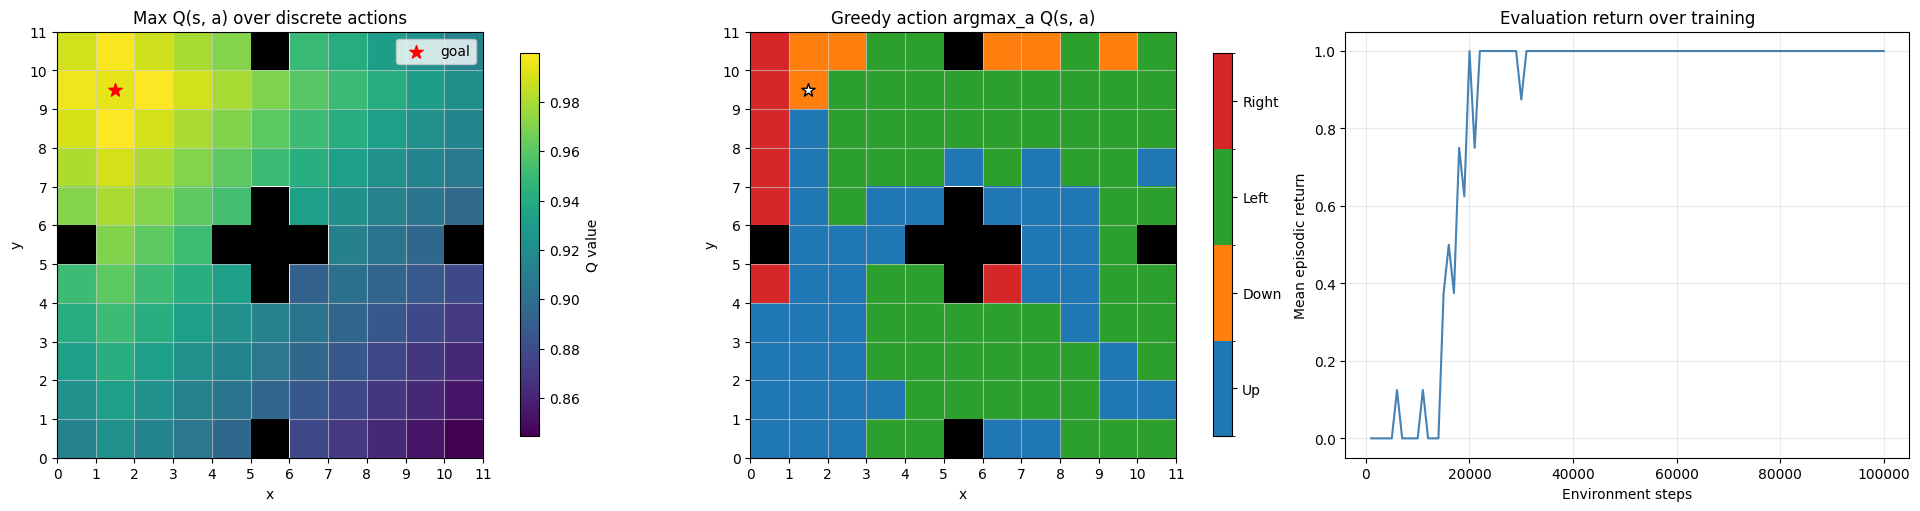

In [ ]:
NEW_GOAL = (1, 9)

new_env = make_env(goal=NEW_GOAL)

# New target network initialised from the first trained factorised network
q_target_new = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)
q_target_new.load_state_dict(dqn_q_new.state_dict())
for p in q_target_new.parameters():
    p.requires_grad_(False)

# Freeze environment representation (phi) and action embedding in q_net;
# only allow psi (goal encoder) to adapt to the new goal.
# for p in dqn_q_new.obs_encoder.parameters():
#     p.requires_grad_(False)
# for p in dqn_q_new.action_emb.parameters():
#     p.requires_grad_(False)
# for p in dqn_q_new.goal_encoder.parameters():
#     p.requires_grad_(True)

# Train only psi(goal) parameters on the new goal
dqn_q_new, dqn_eval_new = dqn_train(
    env=new_env,
    q_network=dqn_q_new,             # same network, re-used env representation
    q_target_network=q_target_new,
    goal=NEW_GOAL,
    # params=dqn_q_new.goal_encoder.parameters(),  # only psi updated
)

if dqn_eval_new:
    xs, ys = zip(*dqn_eval_new)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("Factorised DQN on FourRooms (discrete) on top of pre-trained phi")
    plt.grid(alpha=0.25)
    plt.show()


dqn_q_new.eval()
eval_env_new = make_env(goal=NEW_GOAL)


plot_policy_rollouts(
    env=eval_env_new,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_new, goal=NEW_GOAL),
    goal_pos=NEW_GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=eval_env_new,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_new, goal=NEW_GOAL),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=NEW_GOAL,
    eval_returns=dqn_eval_new,
)

eval_env_new.close()


psi norm 3.5719008445739746
psi norm 3.752082586288452
psi norm 3.7380311489105225
psi norm 3.6539361476898193
psi norm 3.6858558654785156
psi norm 3.7320148944854736
psi norm 3.7988295555114746
psi norm 3.8654661178588867
psi norm 3.930377244949341
psi norm 3.981790781021118
psi norm 4.027113914489746
psi norm 4.06223726272583
psi norm 4.100700855255127
psi norm 4.131698131561279
psi norm 4.162051200866699
psi norm 4.182574272155762
psi norm 4.205885887145996
psi norm 4.224513053894043
psi norm 4.239195346832275


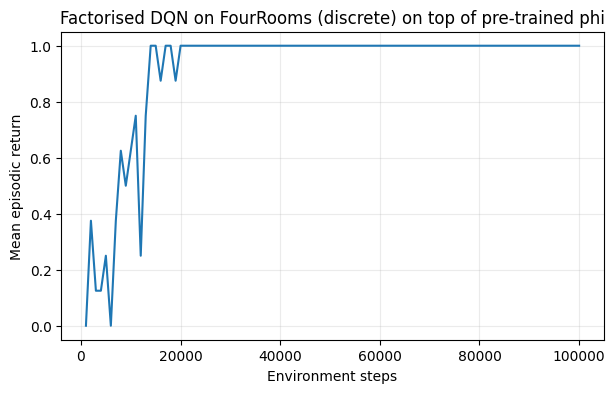

Episode 1: 13 steps | return: 1.00 | reached goal: True
Episode 2: 6 steps | return: 1.00 | reached goal: True
Episode 3: 7 steps | return: 1.00 | reached goal: True
Episode 4: 9 steps | return: 1.00 | reached goal: True
Episode 5: 12 steps | return: 1.00 | reached goal: True
Episode 6: 12 steps | return: 1.00 | reached goal: True
Episode 7: 11 steps | return: 1.00 | reached goal: True
Episode 8: 15 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


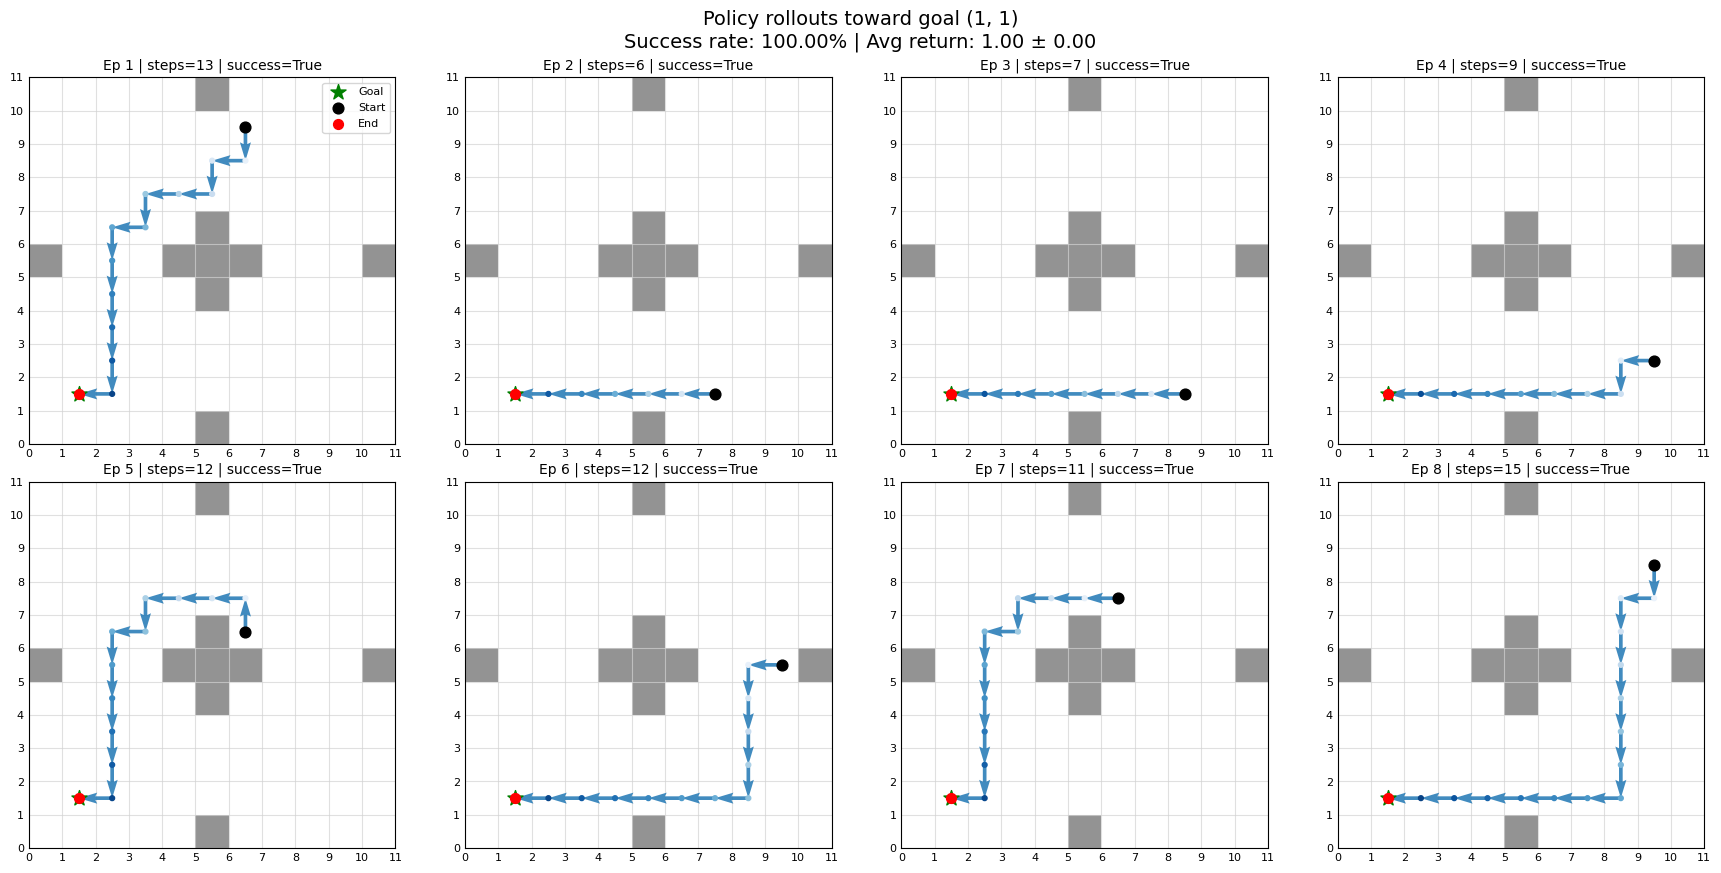

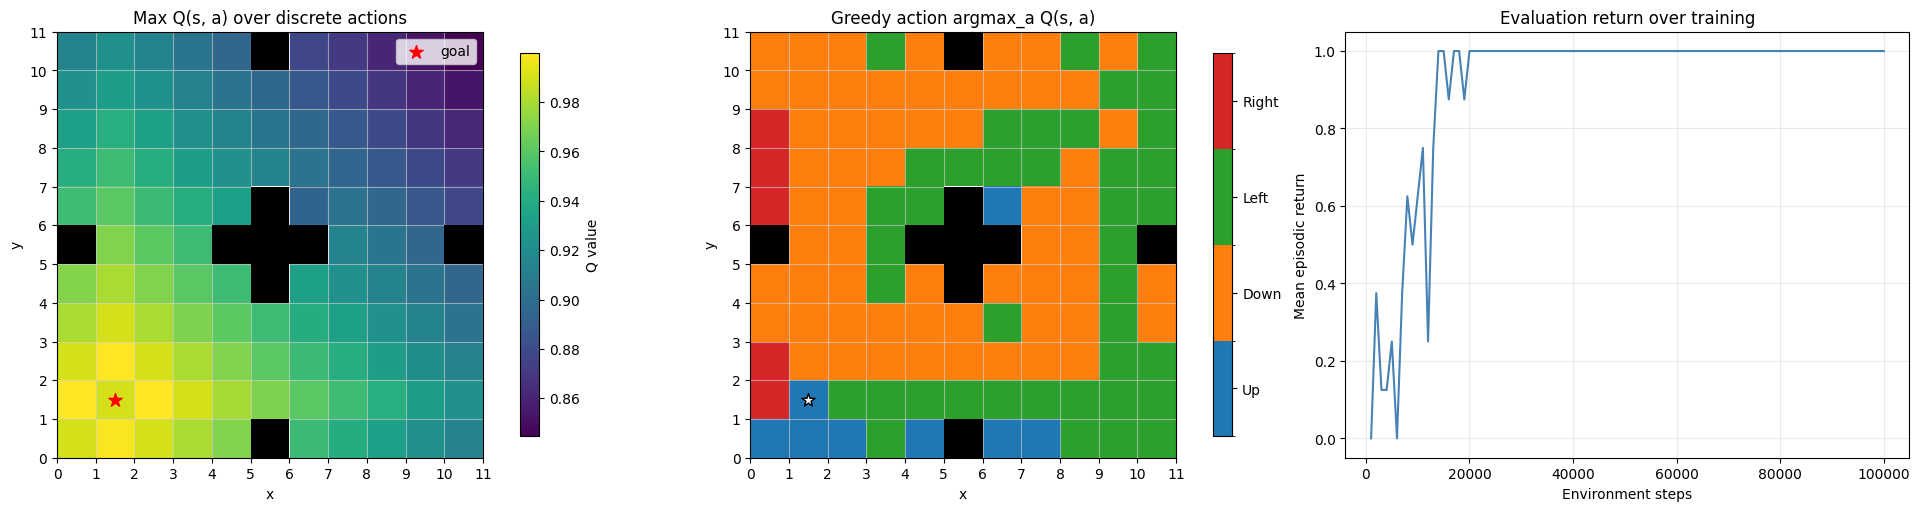

In [12]:
NEW_GOAL = (1, 1)

new_env = make_env(goal=NEW_GOAL)

# New target network initialised from the first trained factorised network
q_target_new = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)
q_target_new.load_state_dict(dqn_q_new.state_dict())
for p in q_target_new.parameters():
    p.requires_grad_(False)

# Freeze environment representation (phi) and action embedding in q_net;
# only allow psi (goal encoder) to adapt to the new goal.
# for p in dqn_q_new.obs_encoder.parameters():
#     p.requires_grad_(False)
# for p in dqn_q_new.action_emb.parameters():
#     p.requires_grad_(False)
# for p in dqn_q_new.goal_encoder.parameters():
#     p.requires_grad_(True)

# Train only psi(goal) parameters on the new goal
dqn_q_new, dqn_eval_new = dqn_train(
    env=new_env,
    q_network=dqn_q_new,             # same network, re-used env representation
    q_target_network=q_target_new,
    goal=NEW_GOAL,
    # params=dqn_q_new.goal_encoder.parameters(),  # only psi updated
)

if dqn_eval_new:
    xs, ys = zip(*dqn_eval_new)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("Factorised DQN on FourRooms (discrete) on top of pre-trained phi")
    plt.grid(alpha=0.25)
    plt.show()


dqn_q_new.eval()
eval_env_new = make_env(goal=NEW_GOAL)


plot_policy_rollouts(
    env=eval_env_new,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_new, goal=NEW_GOAL),
    goal_pos=NEW_GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=eval_env_new,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_new, goal=NEW_GOAL),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=NEW_GOAL,
    eval_returns=dqn_eval_new,
)

eval_env_new.close()


psi norm 4.442267417907715
psi norm 4.817403316497803
psi norm 4.788402557373047
psi norm 4.664695739746094
psi norm 4.545350551605225
psi norm 4.535750865936279
psi norm 4.560408592224121
psi norm 4.591246128082275
psi norm 4.601190090179443
psi norm 4.609513282775879
psi norm 4.6015448570251465
psi norm 4.586482048034668
psi norm 4.560370922088623
psi norm 4.52576208114624
psi norm 4.482386589050293
psi norm 4.433229446411133
psi norm 4.3722944259643555
psi norm 4.2974066734313965
psi norm 4.22739839553833


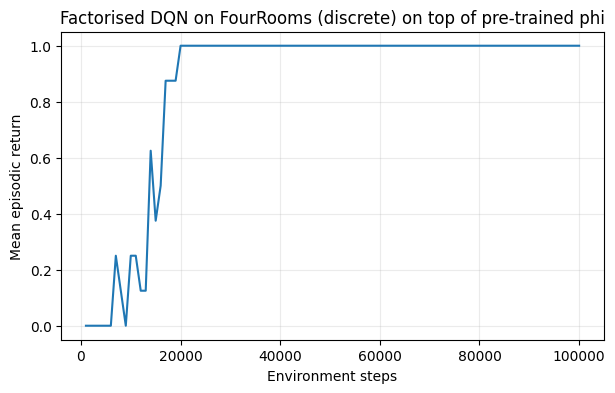

Episode 1: 3 steps | return: 1.00 | reached goal: True
Episode 2: 11 steps | return: 1.00 | reached goal: True
Episode 3: 11 steps | return: 1.00 | reached goal: True
Episode 4: 4 steps | return: 1.00 | reached goal: True
Episode 5: 4 steps | return: 1.00 | reached goal: True
Episode 6: 7 steps | return: 1.00 | reached goal: True
Episode 7: 11 steps | return: 1.00 | reached goal: True
Episode 8: 9 steps | return: 1.00 | reached goal: True

Success rate: 100.00% over 8 episodes
Average return: 1.00 ± 0.00


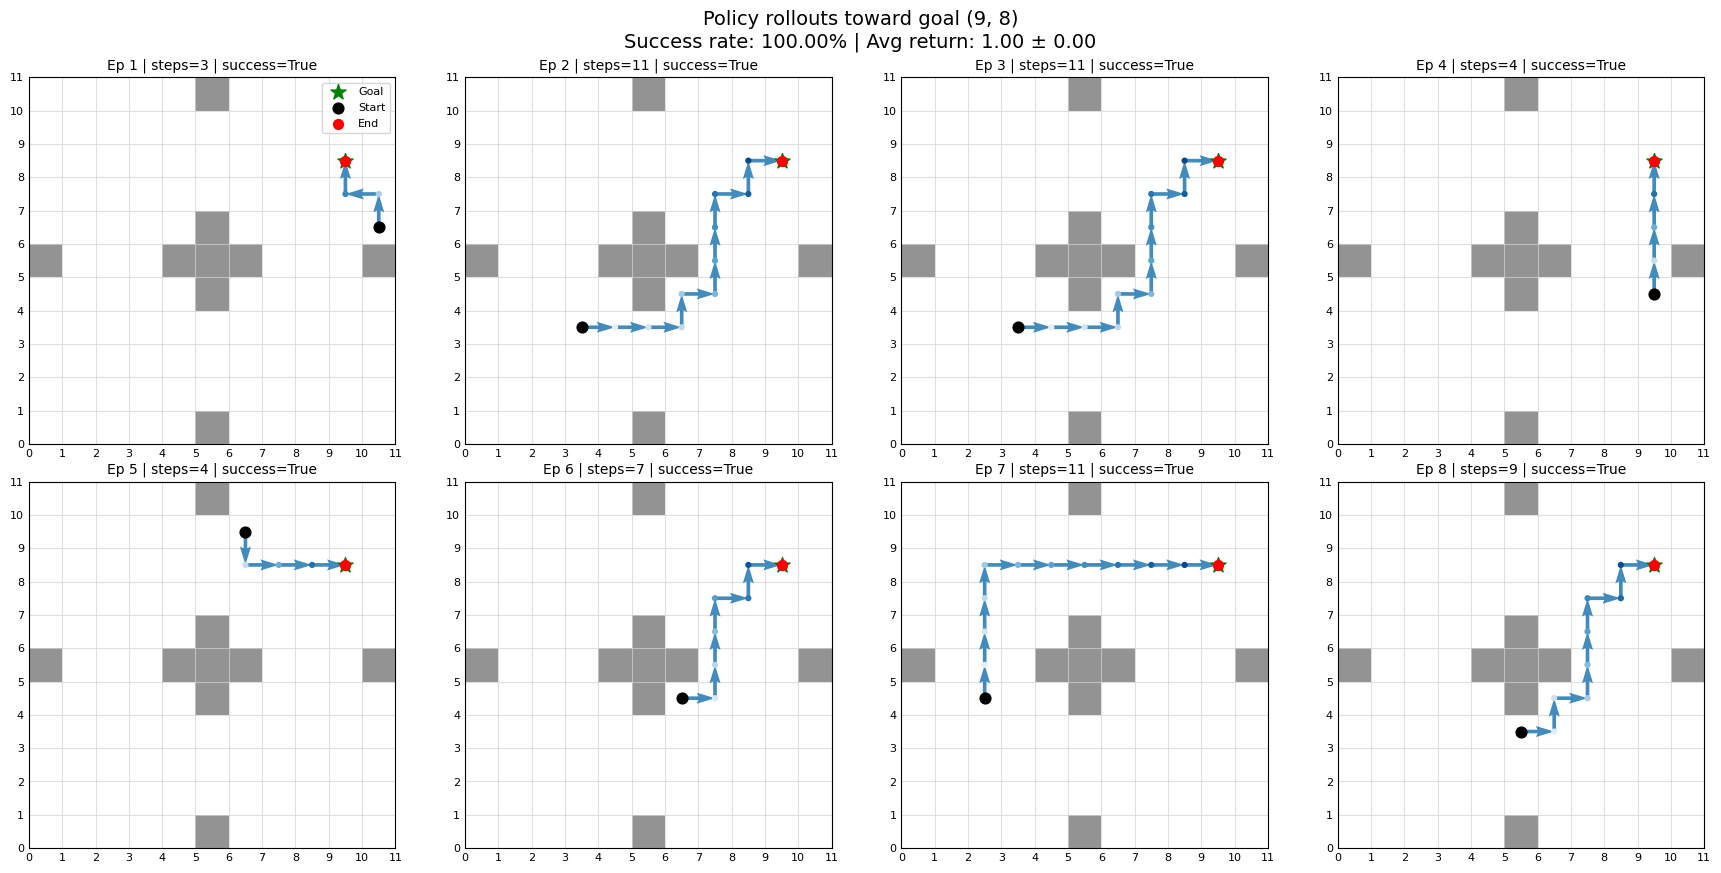

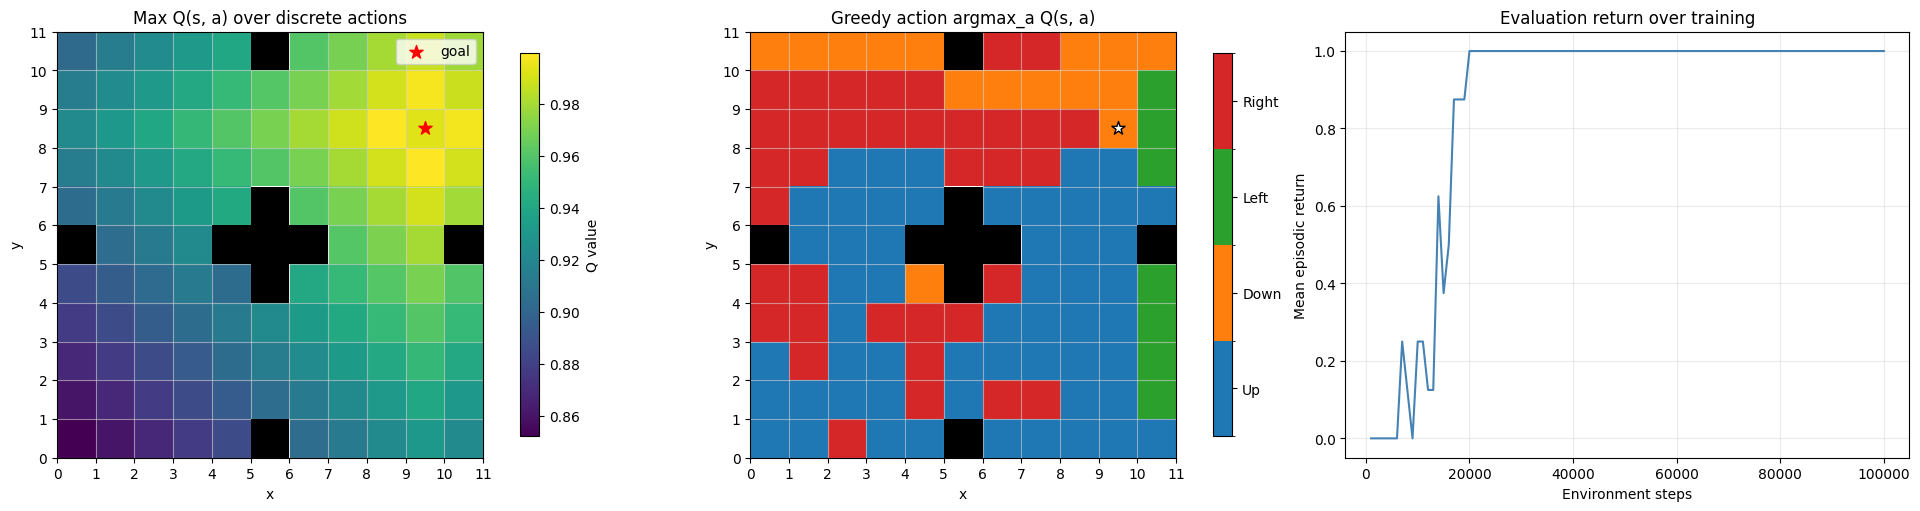

In [13]:
NEW_GOAL = (9, 8)

new_env = make_env(goal=NEW_GOAL)

# New target network initialised from the first trained factorised network
q_target_new = FactorisedDQN_QNetwork(
    obs_dim=obs_dim,
    num_actions=num_actions,
    goal_dim=2,
    hidden_dim=128,
    rep_dim=64,
).to(DEVICE)
q_target_new.load_state_dict(dqn_q_new.state_dict())
for p in q_target_new.parameters():
    p.requires_grad_(False)

# Freeze environment representation (phi) and action embedding in q_net;
# only allow psi (goal encoder) to adapt to the new goal.
# for p in dqn_q_new.obs_encoder.parameters():
#     p.requires_grad_(False)
# for p in dqn_q_new.action_emb.parameters():
#     p.requires_grad_(False)
# for p in dqn_q_new.goal_encoder.parameters():
#     p.requires_grad_(True)

# Train only psi(goal) parameters on the new goal
dqn_q_new, dqn_eval_new = dqn_train(
    env=new_env,
    q_network=dqn_q_new,             # same network, re-used env representation
    q_target_network=q_target_new,
    goal=NEW_GOAL,
    # params=dqn_q_new.goal_encoder.parameters(),  # only psi updated
)

if dqn_eval_new:
    xs, ys = zip(*dqn_eval_new)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel("Environment steps")
    plt.ylabel("Mean episodic return")
    plt.title("Factorised DQN on FourRooms (discrete) on top of pre-trained phi")
    plt.grid(alpha=0.25)
    plt.show()


dqn_q_new.eval()
eval_env_new = make_env(goal=NEW_GOAL)


plot_policy_rollouts(
    env=eval_env_new,
    policy_fn=lambda obs: dqn_policy_fn(obs, q_network=dqn_q_new, goal=NEW_GOAL),
    goal_pos=NEW_GOAL,
    eval_episodes=8,
    n_cols=4,
    is_discrete=True,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

plot_q_diagnostics(
    env=eval_env_new,
    value_fn=lambda obs_batch: dqn_value_fn(obs_batch, q_network=dqn_q_new, goal=NEW_GOAL),
    actor_fn=None,
    is_discrete=True,
    num_actions=4,
    action_names=['Up', 'Down', 'Left', 'Right'],
    goal_pos=NEW_GOAL,
    eval_returns=dqn_eval_new,
)

eval_env_new.close()
